# DefectVision AI - Metal Surface Defect Detection
## Phase 1: Train YOLOv8 on NEU-DET Dataset

This notebook trains a YOLOv8 model to detect 6 types of metal surface defects:
- Crazing
- Inclusion
- Patches
- Pitted surface
- Rolled-in scale
- Scratches

**Supports: Google Colab, Kaggle, and local training.**

1. **Kaggle** (recommended): Use GPU P100 or T4x2 accelerator
2. **Colab**: Go to Runtime > Change runtime type > GPU (T4)
3. **Local**: Requires NVIDIA GPU with CUDA
4. Run all cells and download the trained weights at the end

## Step 1: Install Dependencies

In [1]:
import os, sys

def detect_environment():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
        return "kaggle"
    try:
        import google.colab
        return "colab"
    except ImportError:
        pass
    return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV.upper()}")

if ENV in ("kaggle", "colab"):
    os.system("pip install ultralytics roboflow -q")
    print("Installed ultralytics + roboflow")
else:
    print("Local mode: using existing packages (run 'pip install ultralytics roboflow' if missing)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.4 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==

## Step 2: Check GPU & Configure Training Parameters

In [ ]:
import torch

print(f"Environment:     {ENV.upper()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    VRAM_GB = getattr(props, 'total_memory', getattr(props, 'total_mem', 0)) / 1e9
    DEVICE = 0
    print(f"GPU:             {GPU_NAME}")
    print(f"VRAM:            {VRAM_GB:.1f} GB")
    print(f"CUDA version:    {torch.version.cuda}")

    if VRAM_GB >= 12:
        BATCH_SIZE = 16
        MODEL_SIZE = "yolov8s.pt"
    elif VRAM_GB >= 6:
        BATCH_SIZE = 12
        MODEL_SIZE = "yolov8s.pt"
    elif VRAM_GB >= 4:
        BATCH_SIZE = 8
        MODEL_SIZE = "yolov8n.pt"
    else:
        BATCH_SIZE = 4
        MODEL_SIZE = "yolov8n.pt"
else:
    GPU_NAME = "CPU"
    VRAM_GB = 0
    DEVICE = "cpu"
    BATCH_SIZE = 4
    MODEL_SIZE = "yolov8n.pt"
    print("WARNING: No CUDA GPU detected. Training on CPU will be very slow!")
    if ENV == "kaggle":
        print("  -> Go to Settings (right panel) > Accelerator > GPU P100 or T4x2")
    elif ENV == "colab":
        print("  -> Go to Runtime > Change runtime type > GPU (T4)")

# ========================================================================
# OVERRIDE: Uncomment and change these if you want to force specific values
# ========================================================================
# BATCH_SIZE = 8
# MODEL_SIZE = "yolov8s.pt"   # options: yolov8n.pt, yolov8s.pt, yolov8m.pt
# DEVICE = 0                  # 0 = first GPU, "cpu" = CPU

EPOCHS = 100
PATIENCE = 20
IMG_SIZE = 640

print(f"\n--- Training Config ---")
print(f"Model:      {MODEL_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs:     {EPOCHS} (early stop patience={PATIENCE})")
print(f"Image size: {IMG_SIZE}")
print(f"Device:     {DEVICE}")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

## Step 3: Download NEU-DET Dataset from Roboflow

The NEU Surface Defect Dataset (NEU-DET) is from Northeastern University.
We use the Roboflow-hosted version which comes pre-formatted for YOLOv8.

**To get your free Roboflow API key:**
1. Go to [roboflow.com](https://roboflow.com) and create a free account
2. Go to Settings > API Keys
3. Copy your API key and paste it below

In [ ]:
from roboflow import Roboflow

# Replace with your Roboflow API key
ROBOFLOW_API_KEY = "TV1DtNzZRbCXx3RGZ1py"  # <-- PASTE YOUR KEY HERE

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("siddiqui").project("defect-detection-neu")
version = project.version(4)
dataset = version.download("yolov8")

print(f"\nDataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NEU-Surface-Defect-Dataset-1 in yolov8:: 100%|██████████| 3607/3607 [00:00<00:00, 9758.23it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded to: /kaggle/working/NEU-Surface-Defect-Dataset-1


## Step 4: Explore the Dataset

Let's look at what we downloaded -- the class distribution and some sample images.

In [4]:
import os
import yaml
from pathlib import Path

# Read the data.yaml to see class info
data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset configuration:")
print(f"  Classes: {data_config.get('names', 'N/A')}")
print(f"  Number of classes: {data_config.get('nc', 'N/A')}")

# Count images in each split
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset.location, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"  {split}: {count} images")
    else:
        print(f"  {split}: directory not found")

Dataset configuration:
  Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
  Number of classes: 6
  train: 1439 images
  valid: 360 images
  test: directory not found


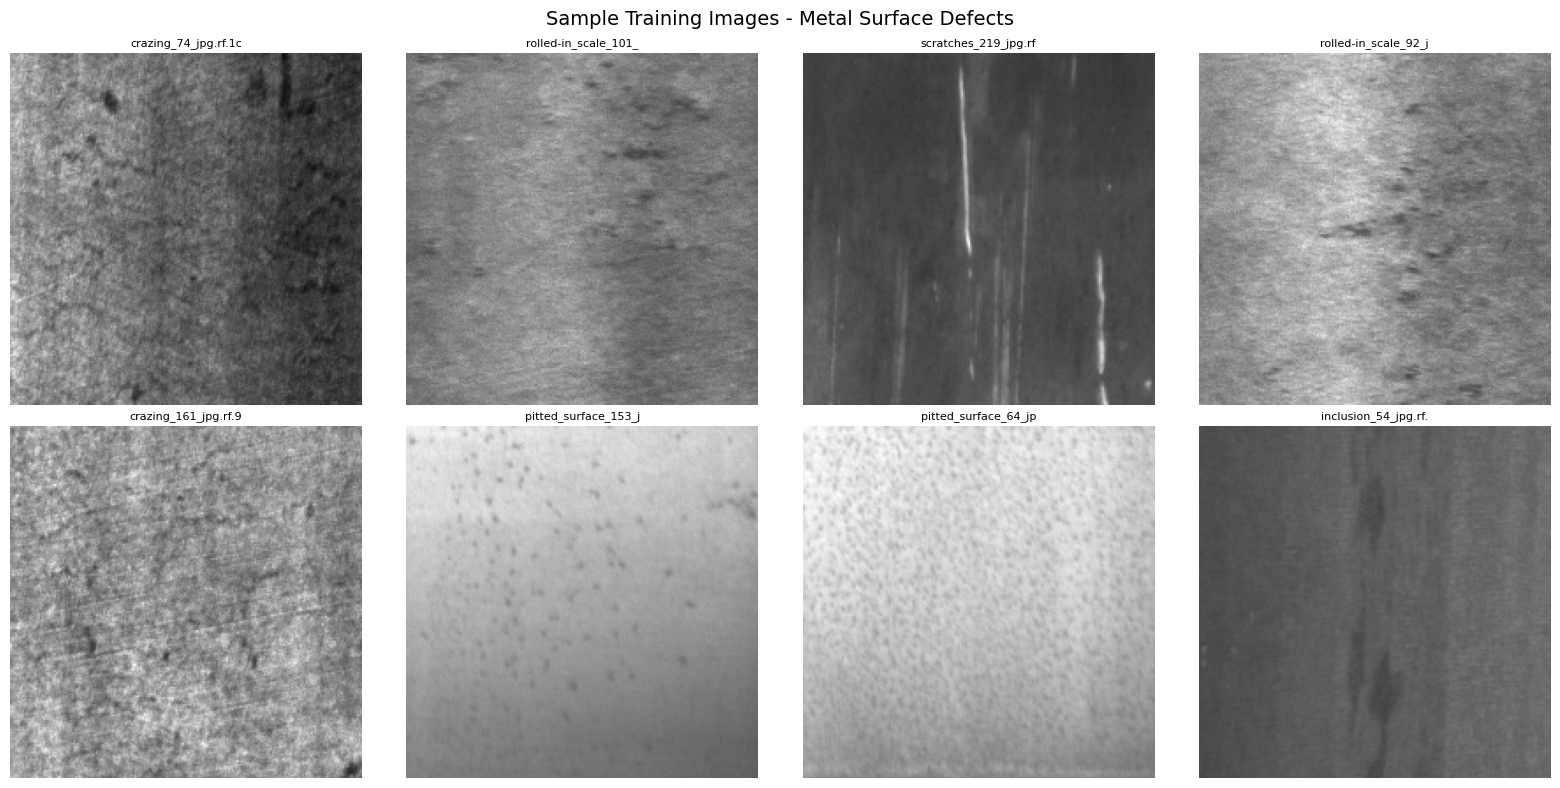

In [5]:
# Visualize some sample images
import matplotlib.pyplot as plt
import cv2
import random

train_img_dir = os.path.join(dataset.location, 'train', 'images')
sample_images = random.sample(os.listdir(train_img_dir), min(8, len(os.listdir(train_img_dir))))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img_name in zip(axes.flatten(), sample_images):
    img = cv2.imread(os.path.join(train_img_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_name[:20], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images - Metal Surface Defects', fontsize=14)
plt.tight_layout()
plt.show()

## Step 5: Train YOLOv8 Model

Model is auto-selected based on GPU VRAM (yolov8s for 6GB+, yolov8n for smaller).

Key training settings for high accuracy on metal defects:
- **100 epochs** with patience=20 early stopping
- **Heavy augmentation**: mosaic, vertical/horizontal flip, HSV shifts, scale jitter
- **Cosine LR schedule** for smoother convergence
- **close_mosaic=15**: disables mosaic in last 15 epochs for fine-tuning on clean images

Expected: **mAP50 > 0.75** (target: 80%+)

Training times:
- **Kaggle P100 / Colab T4** (yolov8s, batch=16): ~35-50 min
- **Local GTX 1650 Ti** (yolov8n, batch=8): ~45-60 min

In [ ]:
from ultralytics import YOLO

print(f"Loading pretrained {MODEL_SIZE}...")
model = YOLO(MODEL_SIZE)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name="metal_defect_detector",
    patience=PATIENCE,
    save=True,
    plots=True,
    device=DEVICE,
    workers=2 if ENV == "local" else 4,
    exist_ok=True,
    # augmentation tuned for metal surface textures
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    close_mosaic=15,
    scale=0.5,
    mixup=0.1,
    cos_lr=True,
)

print("\nTraining complete!")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/NEU-Surface-Defect-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=metal_defect_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

## Step 6: Evaluate the Model

Check the model's performance on the validation set.

In [7]:
# Validate on the validation set
metrics = model.val()

print(f"\n=== Metal Defect Detection Results ===")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 952.0±473.8 MB/s, size: 39.7 KB)
val: Scanning /kaggle/working/NEU-Surface-Defect-Dataset-1/valid/labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 151.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 4.6it/s 4.9s0.1s
                   all        360        854      0.359      0.572      0.425      0.183
               crazing         60        162      0.452       0.26      0.314      0.101
             inclusion         71        159      0.416      0.692      0.581      0.234
               patches         73        193      0.546      0.803      0.751      0.444
        pitted_surface         60         87      0.481      0.402      0.458      0.189
       rolled-in_s


--- results.png ---


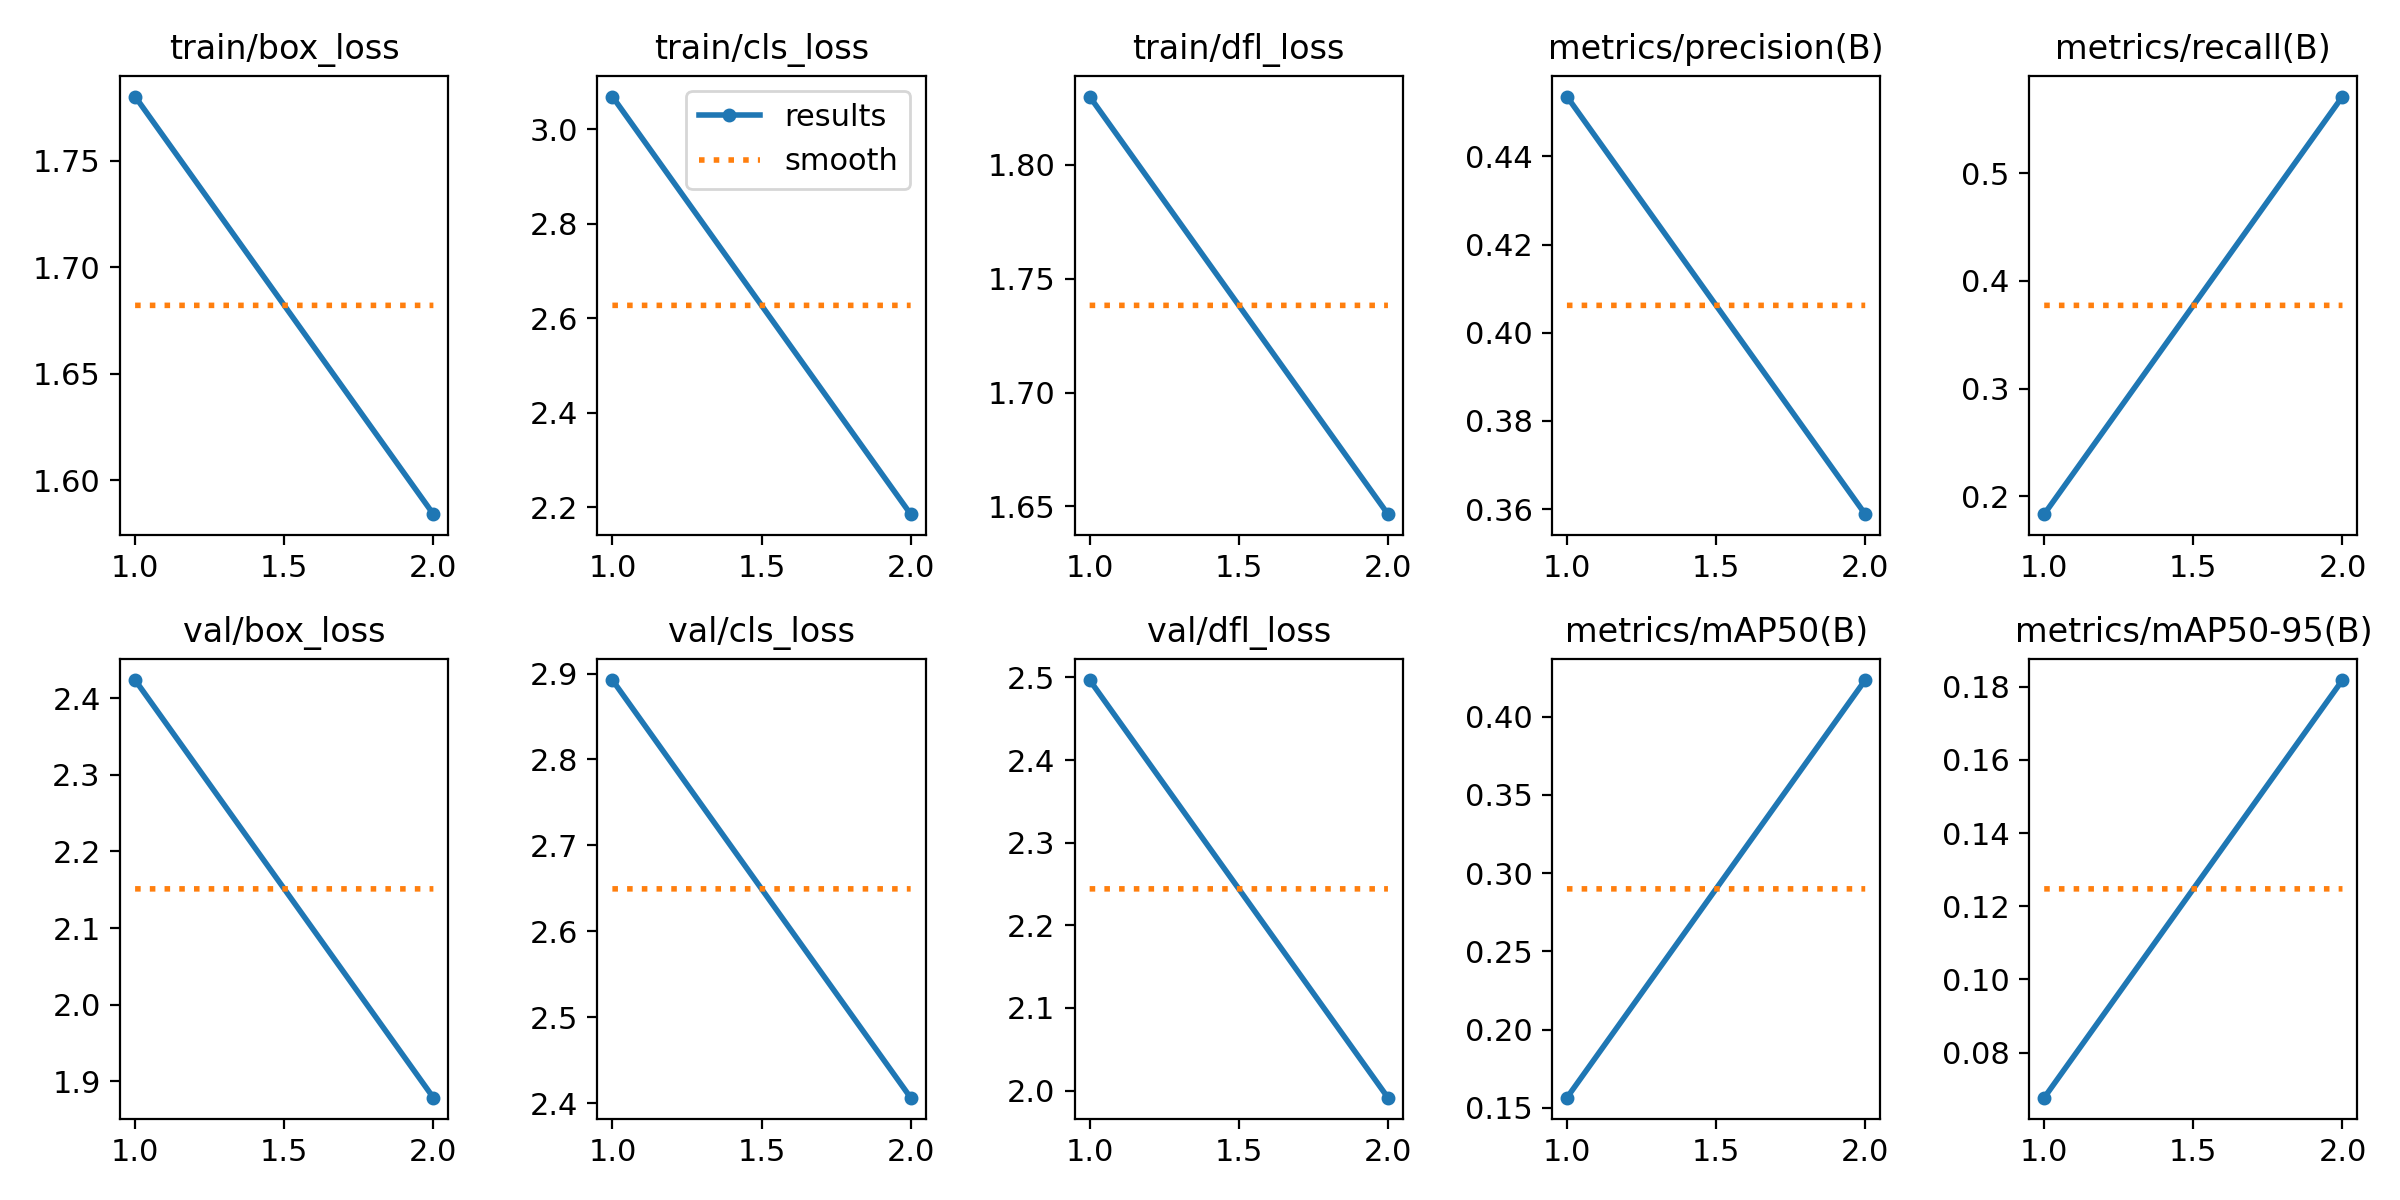


--- confusion_matrix.png ---


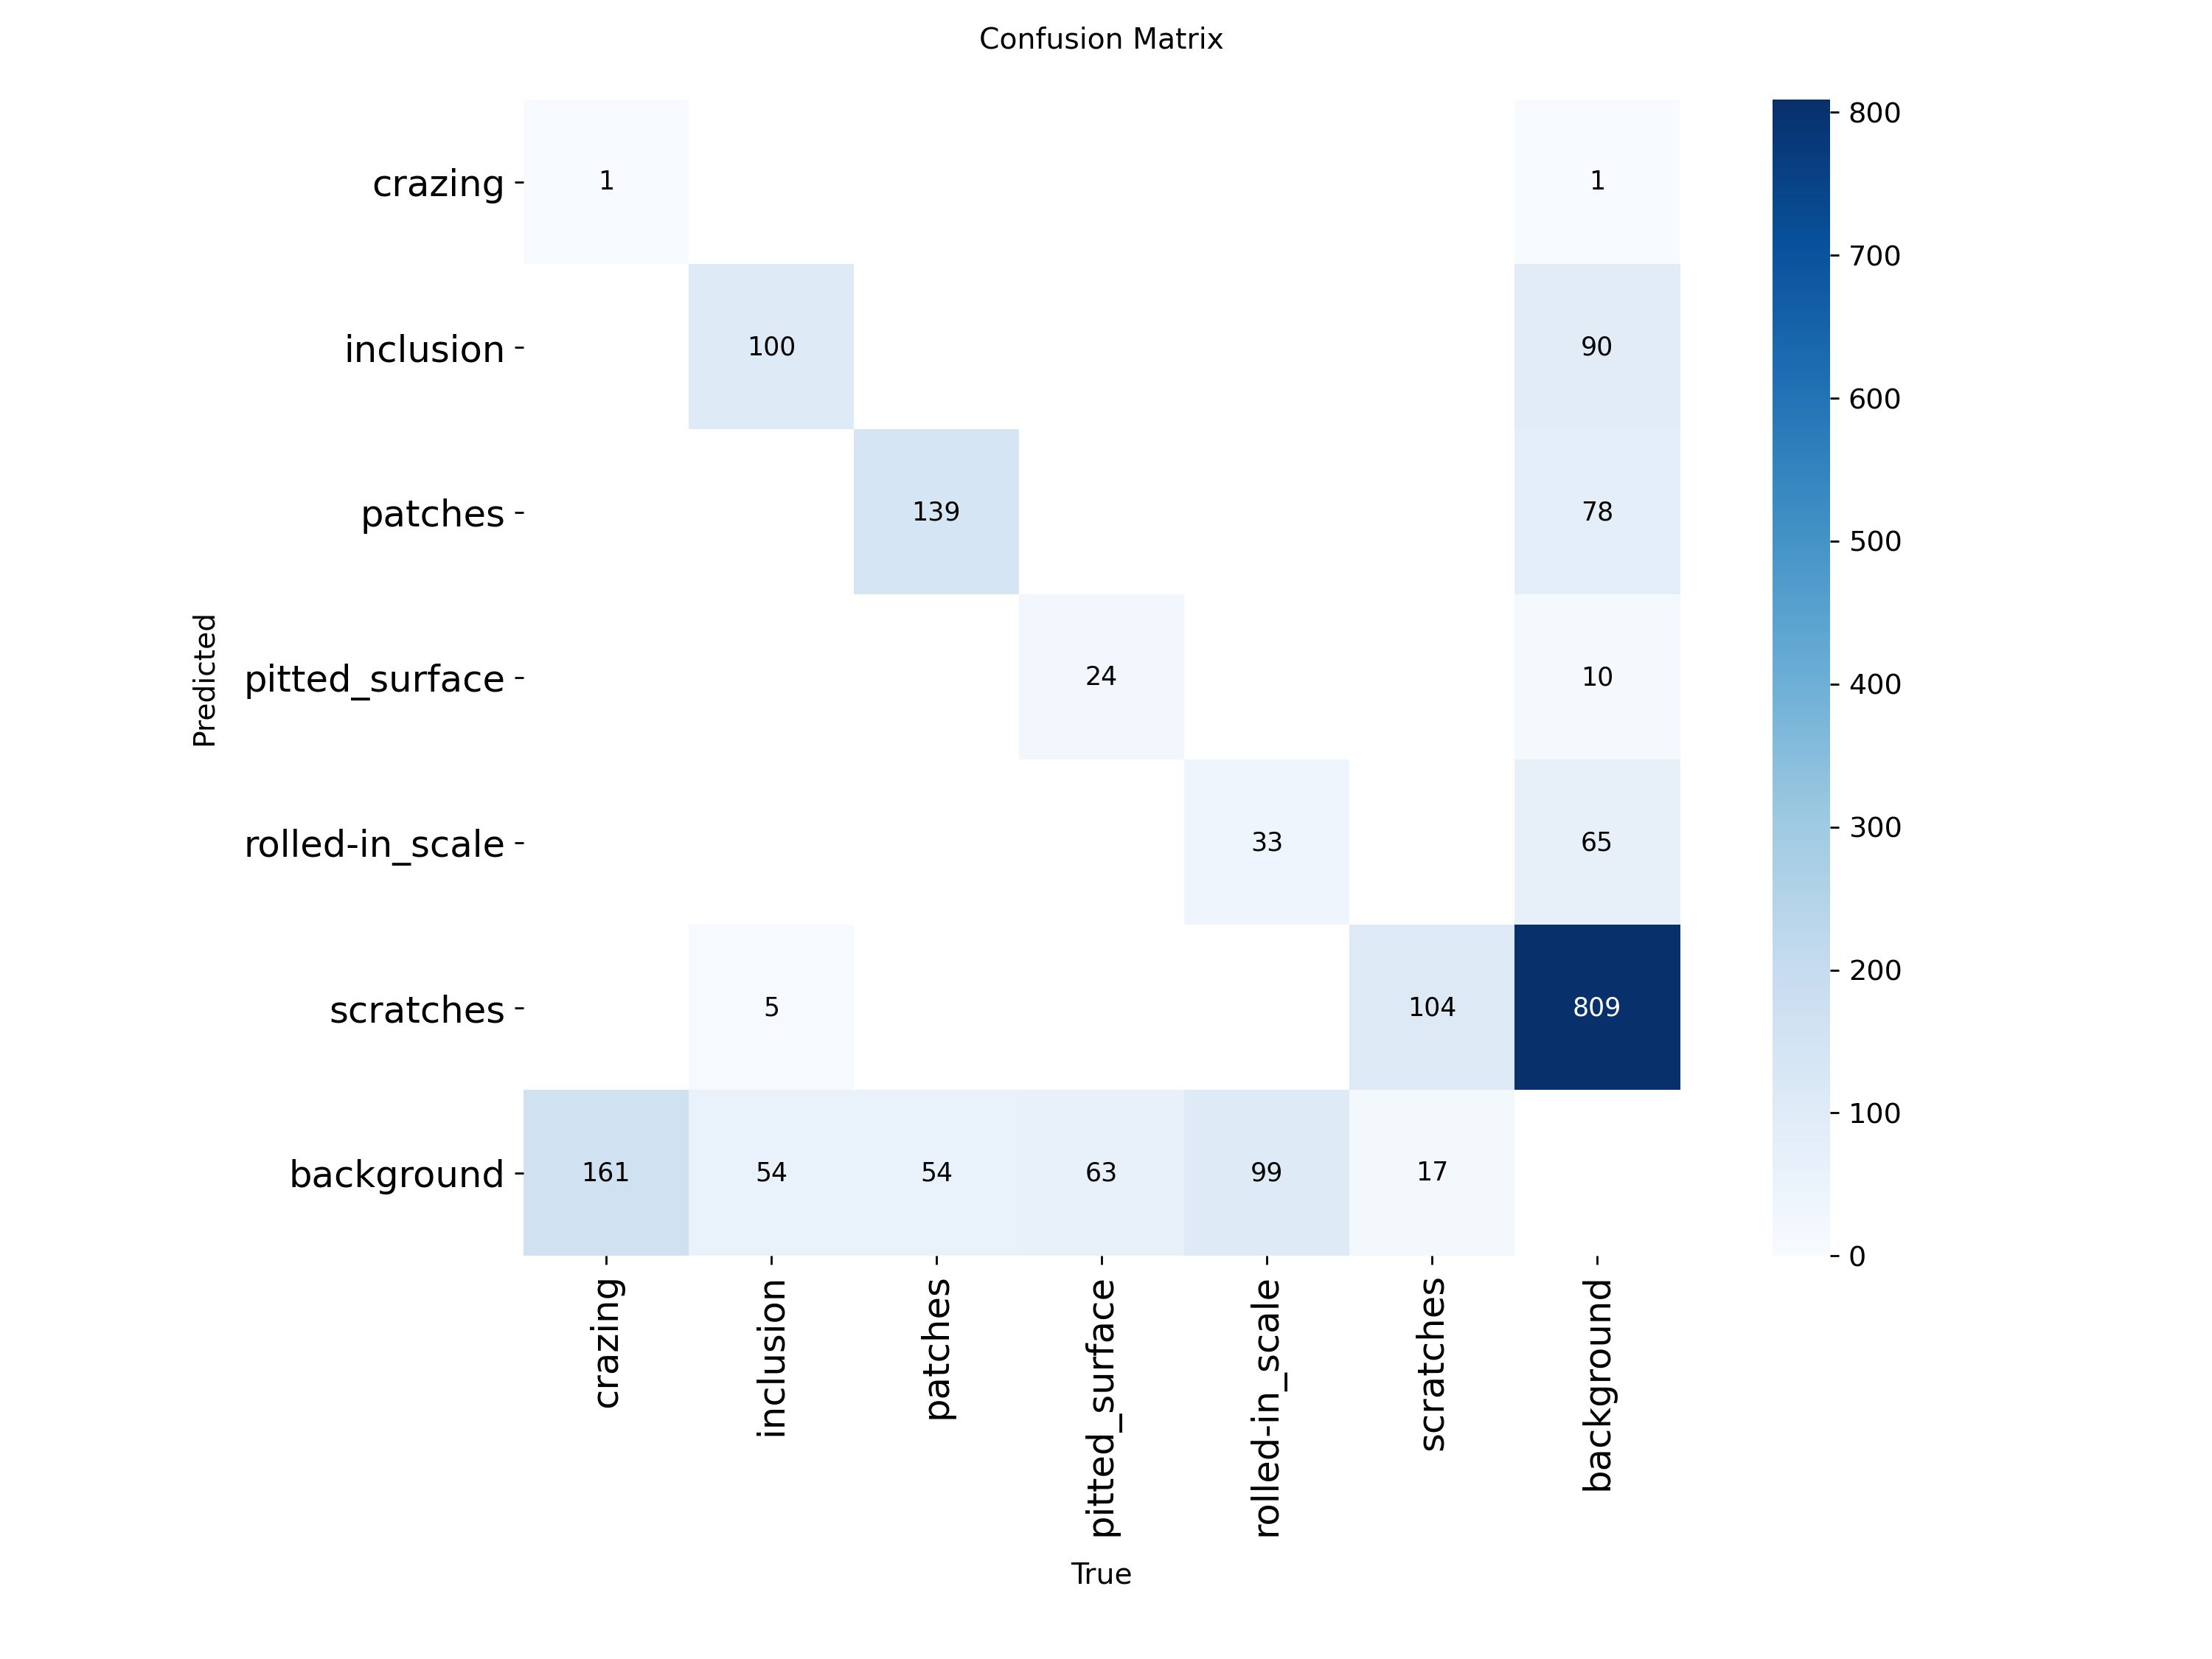

In [8]:
# Show training curves
from IPython.display import Image, display

# Display training results
results_dir = Path("runs/detect/metal_defect_detector")

for plot_name in ["results.png", "confusion_matrix.png", "val_batch0_pred.png"]:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        print(f"\n--- {plot_name} ---")
        display(Image(filename=str(plot_path), width=800))

## Step 7: Test on Sample Images

Run inference on validation images to see the detections.

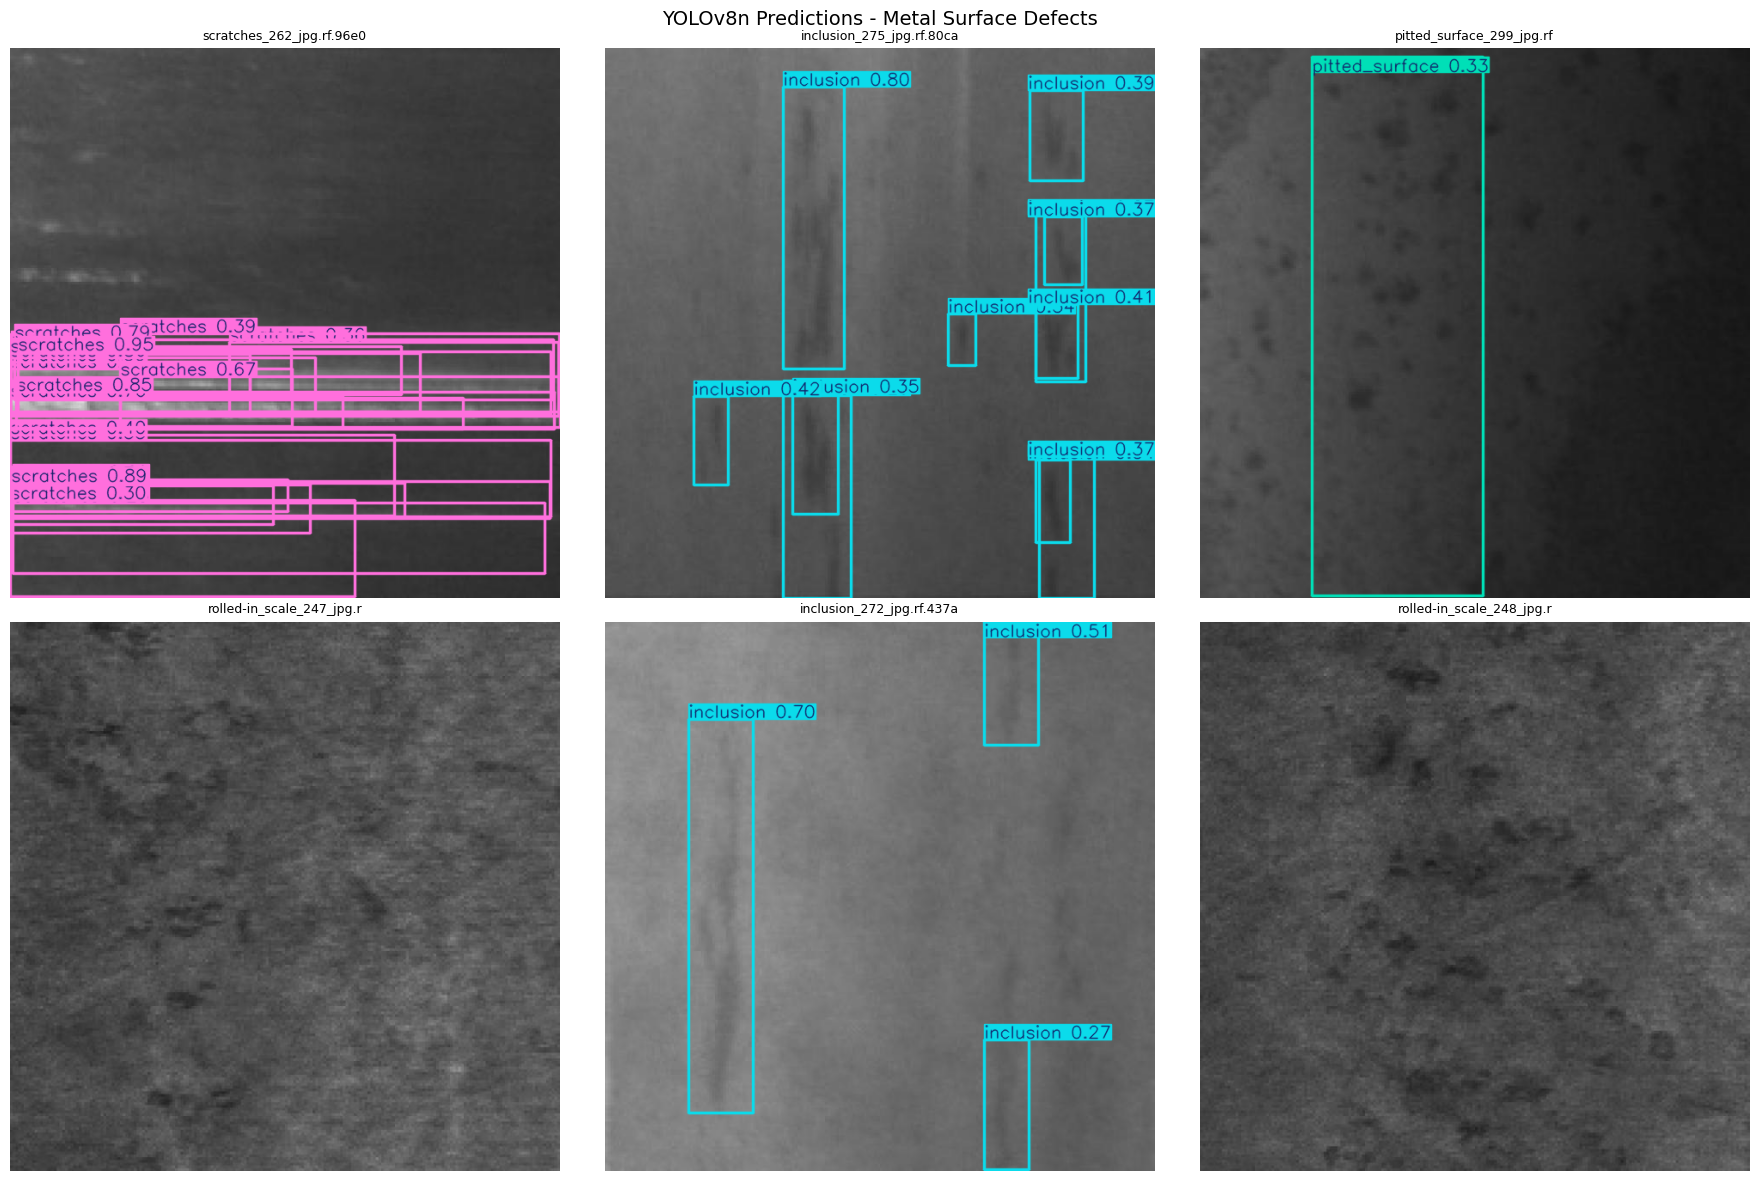

In [9]:
# Run inference on validation images
val_img_dir = os.path.join(dataset.location, 'valid', 'images')
if not os.path.exists(val_img_dir):
    val_img_dir = os.path.join(dataset.location, 'test', 'images')

val_images = os.listdir(val_img_dir)
sample_val = random.sample(val_images, min(6, len(val_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_name in zip(axes.flatten(), sample_val):
    img_path = os.path.join(val_img_dir, img_name)
    results = model(img_path, conf=0.25, verbose=False)
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(img_name[:25], fontsize=9)
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions - Metal Surface Defects', fontsize=14)
plt.tight_layout()
plt.show()

## Step 8: Download Trained Weights

Download the `best.pt` file and place it in your local project at:
```
defect-vision/models/metal_yolo_best.pt
```

In [10]:
import shutil

best_weights = Path("runs/detect/metal_defect_detector/weights/best.pt")
if best_weights.exists():
    shutil.copy(best_weights, "metal_yolo_best.pt")
    print(f"Best weights saved to: metal_yolo_best.pt")
    print(f"File size: {best_weights.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Could not find best.pt at {best_weights} - check the runs/ directory")

try:
    from google.colab import files
    files.download("metal_yolo_best.pt")
    print("\nDownload started! Save it to models/metal_yolo_best.pt")
except ImportError:
    if ENV == "kaggle":
        print("\nKaggle: find metal_yolo_best.pt in the Output tab")
    else:
        print("\nLocal: copy metal_yolo_best.pt to models/metal_yolo_best.pt")

Best weights saved to: metal_yolo_best.pt
File size: 6.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started! Save it to defect-vision/models/metal_yolo_best.pt
